In [34]:
import xarray as xr

# ds = xr.open_zarr("/home/alden/code/dynamical/reformatters/data/output/noaa-gefs-analysis/vdev.zarr")
ds

<xarray.Dataset> Size: 105TB
Dimensions:                                     (init_time: 5752,
                                                 lead_time: 209, latitude: 721,
                                                 longitude: 1440)
Coordinates:
  * latitude                                    (latitude) float64 6kB 90.0 ....
  * lead_time                                   (lead_time) timedelta64[ns] 2kB ...
    ingested_forecast_length                    (init_time) timedelta64[ns] 46kB ...
  * init_time                                   (init_time) datetime64[ns] 46kB ...
  * longitude                                   (longitude) float64 12kB -180...
    expected_forecast_length                    (init_time) timedelta64[ns] 46kB ...
    spatial_ref                                 int64 8B ...
    valid_time                                  (init_time, lead_time) datetime64[ns] 10MB ...
Data variables: (12/21)
    categorical_ice_pellets_surface             (init_time, lead_time, latitude, longitude) float32 5TB ...
    categorical_freezing_rain_surface           (init_time, lead_time, latitude, longitude) float32 5TB ...
    downward_long_wave_radiation_flux_surface   (init_time, lead_time, latitude, longitude) float32 5TB ...
    categorical_snow_surface                    (init_time, lead_time, latitude, longitude) float32 5TB ...
    geopotential_height_cloud_ceiling           (init_time, lead_time, latitude, longitude) float32 5TB ...
    categorical_rain_surface                    (init_time, lead_time, latitude, longitude) float32 5TB ...
    ...                                          ...
    temperature_2m                              (init_time, lead_time, latitude, longitude) float32 5TB ...
    wind_u_100m                                 (init_time, lead_time, latitude, longitude) float32 5TB ...
    total_cloud_cover_atmosphere                (init_time, lead_time, latitude, longitude) float32 5TB ...
    wind_v_100m                                 (init_time, lead_time, latitude, longitude) float32 5TB ...
    wind_u_10m                                  (init_time, lead_time, latitude, longitude) float32 5TB ...
    wind_v_10m                                  (init_time, lead_time, latitude, longitude) float32 5TB ...
Attributes:
    dataset_id:           noaa-gfs-forecast
    dataset_version:      0.1.0
    name:                 NOAA GFS forecast
    description:          Weather forecasts from the Global Forecast System (...
    attribution:          NOAA NWS NCEP GFS data processed by dynamical.org f...
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2021-05-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours.
    forecast_domain:      Forecast lead time 0-384 hours (0-16 days) ahead
    forecast_resolution:  Forecast step 0-120 hours: hourly, 123-384 hours: 3...

In [35]:
ds["temperature_2m"].sel(
    time="2019-12-30T09:00",
    latitude=slice(70, 0),
    longitude=slice(0, 70),
).plot()

KeyError: "'time' is not a valid dimension or coordinate for Dataset with dimensions FrozenMappingWarningOnValuesAccess({'latitude': 721, 'lead_time': 209, 'init_time': 5752, 'longitude': 1440})"

In [38]:
ds

<xarray.Dataset> Size: 613GB
Dimensions:                (longitude: 1440, latitude: 721, time: 73784)
Coordinates:
  * longitude              (longitude) float64 12kB -180.0 -179.8 ... 179.8
  * latitude               (latitude) float64 6kB 90.0 89.75 ... -89.75 -90.0
  * time                   (time) datetime64[ns] 590kB 2000-01-01 ... 2025-04...
    spatial_ref            int64 8B ...
Data variables:
    precipitation_surface  (time, latitude, longitude) float32 306GB ...
    temperature_2m         (time, latitude, longitude) float32 306GB ...
Attributes:
    dataset_id:          noaa-gefs-analysis
    dataset_version:     0.0.1-dev
    name:                NOAA GEFS analysis
    description:         Weather analysis from the Global Ensemble Forecast S...
    attribution:         NOAA NWS NCEP GEFS data processed by dynamical.org f...
    spatial_domain:      Global
    spatial_resolution:  0.25 degrees (~20km)
    time_domain:         2000-01-01 00:00:00 UTC to Present
    time_resolution:     3.0 hours

In [29]:
import xarray as xr
import zarr
import obstore

# zarr.config.set( { "async.concurrency": 128, })

zarr.config.set(
    {
        "async.concurrency": 512,
        # "threading.max_workers": 128,
        "codec_pipeline": {
            "batch_size": 1,
            "path": "zarr.core.codec_pipeline.BatchedCodecPipeline",
        },
    }
)

# store=zarr.storage.ObjectStore(
#     obstore.store.S3Store(
#         region="us-west-2",
#         bucket="us-west-2.opendata.source.coop",
#         prefix="/dynamical/noaa-gefs-analysis/vchunks-180d-time-first-dev.zarr",
#         skip_signature=True,
#     ),
#     read_only=True,
# )
# store=zarr.storage.ObjectStore(
#     obstore.store.HTTPStore.from_url(
#         "https://data.dynamical.org/noaa/gefs/analysis/vchunks-180d-time-first-dev.zarr"
#     ),
#     read_only=True,
# )
# store = zarr.storage.FsspecStore.from_url(
#     # "s3://us-west-2.opendata.source.coop/dynamical/noaa-gefs-analysis/vchunks-180d-time-first-dev.zarr",
#     "https://data.dynamical.org/noaa/gefs/analysis/vchunks-180d-time-first-dev.zarr",
#     read_only=True,
# )

ds = xr.open_zarr("s3://us-west-2.opendata.source.coop/dynamical/noaa-gfs-forecast/v0.1.0.zarr", chunks=None, decode_timedelta=True)
# ds = xr.open_zarr("https://data.dynamical.org/noaa/gefs/analysis/v0.1.0.zarr", chunks=None)
# ds = xr.open_zarr("https://data.dynamical.org/noaa/gefs/analysis/vchunks-180d-time-first-dev.zarr", chunks=None)
# ds = xr.open_zarr("https://data.dynamical.org/noaa/gefs/analysis/vchunks-180d-time-last-dev.zarr", chunks=None)
# ds = xr.open_zarr(store, chunks=None)
ds

<xarray.Dataset> Size: 7TB
Dimensions:                                     (init_time: 368,
                                                 lead_time: 209, latitude: 721,
                                                 longitude: 1440)
Coordinates:
  * latitude                                    (latitude) float64 6kB 90.0 ....
  * init_time                                   (init_time) datetime64[ns] 3kB ...
    ingested_forecast_length                    (init_time) timedelta64[ns] 3kB ...
    expected_forecast_length                    (init_time) timedelta64[ns] 3kB ...
  * longitude                                   (longitude) float64 12kB -180...
  * lead_time                                   (lead_time) timedelta64[ns] 2kB ...
    spatial_ref                                 int64 8B ...
    valid_time                                  (init_time, lead_time) datetime64[ns] 615kB ...
Data variables: (12/21)
    categorical_ice_pellets_surface             (init_time, lead_time, latitude, longitude) float32 319GB ...
    categorical_freezing_rain_surface           (init_time, lead_time, latitude, longitude) float32 319GB ...
    categorical_rain_surface                    (init_time, lead_time, latitude, longitude) float32 319GB ...
    downward_long_wave_radiation_flux_surface   (init_time, lead_time, latitude, longitude) float32 319GB ...
    downward_short_wave_radiation_flux_surface  (init_time, lead_time, latitude, longitude) float32 319GB ...
    geopotential_height_cloud_ceiling           (init_time, lead_time, latitude, longitude) float32 319GB ...
    ...                                          ...
    temperature_2m                              (init_time, lead_time, latitude, longitude) float32 319GB ...
    total_cloud_cover_atmosphere                (init_time, lead_time, latitude, longitude) float32 319GB ...
    wind_u_10m                                  (init_time, lead_time, latitude, longitude) float32 319GB ...
    wind_v_10m                                  (init_time, lead_time, latitude, longitude) float32 319GB ...
    wind_v_100m                                 (init_time, lead_time, latitude, longitude) float32 319GB ...
    wind_u_100m                                 (init_time, lead_time, latitude, longitude) float32 319GB ...
Attributes:
    dataset_id:           noaa-gfs-forecast
    dataset_version:      0.1.0
    name:                 NOAA GFS forecast
    description:          Weather forecasts from the Global Forecast System (...
    attribution:          NOAA NWS NCEP GFS data processed by dynamical.org f...
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2021-05-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours.
    forecast_domain:      Forecast lead time 0-384 hours (0-16 days) ahead
    forecast_resolution:  Forecast step 0-120 hours: hourly, 123-384 hours: 3...

In [15]:
ds.valid_time.values

array([['2021-05-01T00:00:00.000000000', '2021-05-01T01:00:00.000000000',
        '2021-05-01T02:00:00.000000000', ...,
        '2021-05-16T18:00:00.000000000', '2021-05-16T21:00:00.000000000',
        '2021-05-17T00:00:00.000000000'],
       ['2021-05-01T06:00:00.000000000', '2021-05-01T07:00:00.000000000',
        '2021-05-01T08:00:00.000000000', ...,
        '2021-05-17T00:00:00.000000000', '2021-05-17T03:00:00.000000000',
        '2021-05-17T06:00:00.000000000'],
       ['2021-05-01T12:00:00.000000000', '2021-05-01T13:00:00.000000000',
        '2021-05-01T14:00:00.000000000', ...,
        '2021-05-17T06:00:00.000000000', '2021-05-17T09:00:00.000000000',
        '2021-05-17T12:00:00.000000000'],
       ...,
       ['2021-07-31T06:00:00.000000000', '2021-07-31T07:00:00.000000000',
        '2021-07-31T08:00:00.000000000', ...,
        '2021-08-16T00:00:00.000000000', '2021-08-16T03:00:00.000000000',
        '2021-08-16T06:00:00.000000000'],
       ['2021-07-31T12:00:00.000000000', '20

In [14]:
import pandas as pd
pd.to_timedelta(ds.lead_time.values)

TimedeltaIndex([ '0 days 00:00:00',  '0 days 01:00:00',  '0 days 02:00:00',
                 '0 days 03:00:00',  '0 days 04:00:00',  '0 days 05:00:00',
                 '0 days 06:00:00',  '0 days 07:00:00',  '0 days 08:00:00',
                 '0 days 09:00:00',
                ...
                '14 days 21:00:00', '15 days 00:00:00', '15 days 03:00:00',
                '15 days 06:00:00', '15 days 09:00:00', '15 days 12:00:00',
                '15 days 15:00:00', '15 days 18:00:00', '15 days 21:00:00',
                '16 days 00:00:00'],
               dtype='timedelta64[ns]', length=209, freq=None)

In [ ]:
# ds["precipitation_surface"].sel(latitude=slice(50, 20), longitude=slice(-120, -60)).mean(dim=("latitude", "longitude")).plot()
ds["precipitation_surface"].sel(latitude=slice(-20, -50), longitude=slice(60, 120)).max(dim=("latitude", "longitude")).plot()

In [17]:
ds["temperature_2m"].sel(latitude=slice(-40,-42), longitude=slice(170,172), lead_time=slice('5h'))

<xarray.DataArray 'temperature_2m' (init_time: 368, lead_time: 6, latitude: 9,
                                    longitude: 9)> Size: 715kB
[178848 values with dtype=float32]
Coordinates:
  * latitude                  (latitude) float64 72B -40.0 -40.25 ... -42.0
  * init_time                 (init_time) datetime64[ns] 3kB 2021-05-01 ... 2...
    ingested_forecast_length  (init_time) timedelta64[ns] 3kB NaT NaT ... NaT
    expected_forecast_length  (init_time) timedelta64[ns] 3kB 16 days ... 16 ...
  * longitude                 (longitude) float64 72B 170.0 170.2 ... 172.0
  * lead_time                 (lead_time) timedelta64[ns] 48B 00:00:00 ... 05...
    spatial_ref               int64 8B 0
    valid_time                (init_time, lead_time) datetime64[ns] 18kB 2021...
Attributes:
    long_name:      2 metre temperature
    short_name:     t2m
    standard_name:  air_temperature
    units:          C
    step_type:      instant

categorical_freezing_rain_surface 0.0 1.0
categorical_ice_pellets_surface 0.0 0.0


/tmp/ipykernel_1545461/3615294646.py:21: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(vmin, vmax)


categorical_rain_surface 0.0 1.0
categorical_snow_surface 0.0 1.0
downward_long_wave_radiation_flux_surface 202.0 402.0
downward_short_wave_radiation_flux_surface 0.0 572.0
geopotential_height_cloud_ceiling 10.75 20032.0
maximum_temperature_2m -3.375 18.5
minimum_temperature_2m -5.1875 18.375
percent_frozen_precipitation_surface -50.0 88.0
precipitable_water_atmosphere 2.140625 38.5
precipitation_surface 0.0 0.004974365234375
pressure_reduced_to_mean_sea_level 97536.0 104064.0
pressure_surface 91328.0 103936.0
relative_humidity_2m 35.75 100.0
temperature_2m -5.0625 18.375
total_cloud_cover_atmosphere 0.0 100.0
wind_u_100m -25.5 30.75
wind_u_10m -20.75 24.0
wind_v_100m -31.25 23.5
wind_v_10m -24.25 19.5


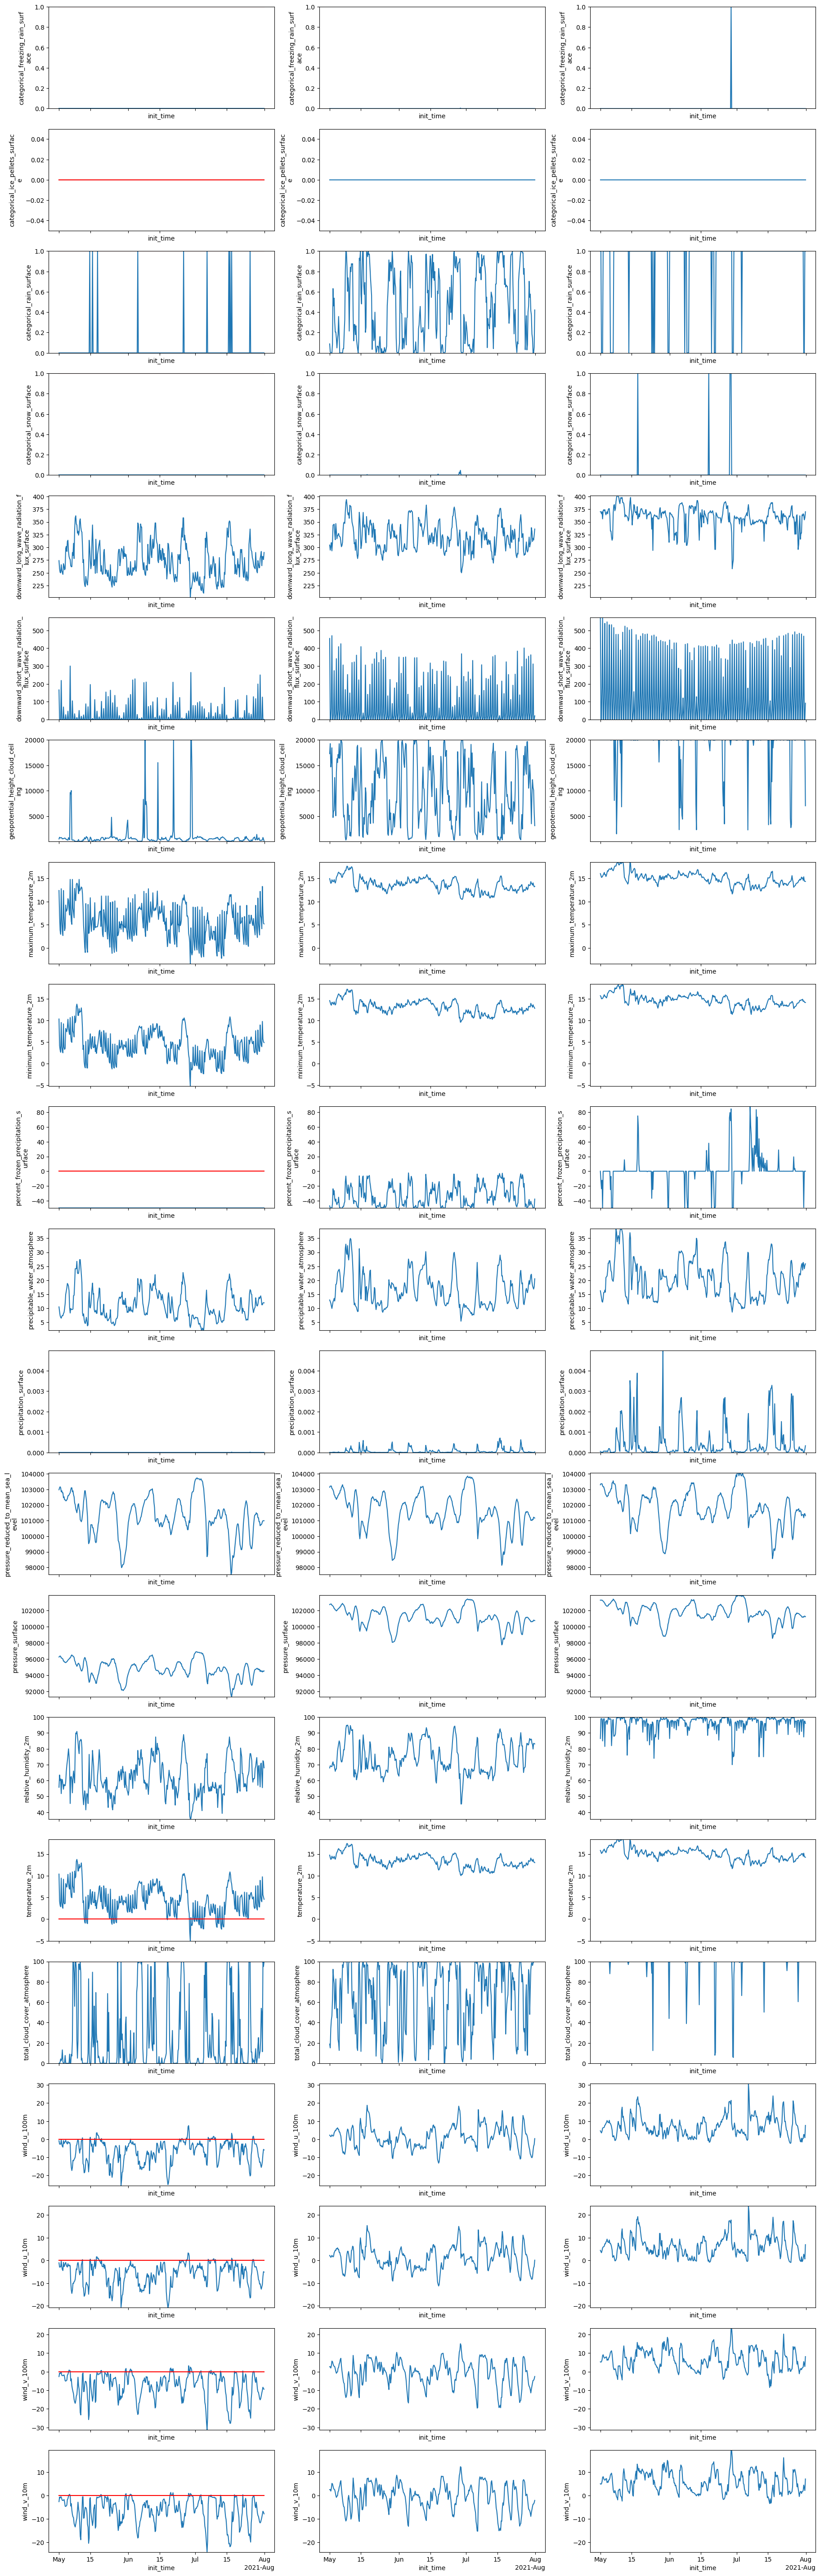

In [31]:
import matplotlib.pyplot as plt
import numpy as np

var_names = sorted(ds.data_vars.keys())
fig, axes = plt.subplots(len(var_names), 3, figsize=(22, 3.5 * len(var_names)), sharex=True)

for i, var_name in enumerate(var_names):
    row_axes = axes[i]

    data_array = ds[var_name].sel(latitude=slice(-40,-42), longitude=slice(170,172), lead_time=slice('5h')).load()
    vmin, vmax = data_array.min().item(), data_array.max().item()
    print(var_name, vmin, vmax)

    data_array.min(dim=("latitude", "longitude", "lead_time")).plot(ax=row_axes[0], x="init_time")
    data_array.mean(dim=("latitude", "longitude", "lead_time")).plot(ax=row_axes[1], x="init_time")
    data_array.max(dim=("latitude", "longitude", "lead_time")).plot(ax=row_axes[2], x="init_time")
    (data_array.isnull().any(dim=("latitude", "longitude", "lead_time")) * vmax).plot(ax=row_axes[0], color='red', x="init_time")

    for ax in row_axes:
        ax.set_title("")
        ax.set_ylim(vmin, vmax)

/tmp/ipykernel_1545461/3488750178.py:20: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(vmin, vmax)
/tmp/ipykernel_1545461/3488750178.py:20: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(vmin, vmax)
/tmp/ipykernel_1545461/3488750178.py:20: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(vmin, vmax)


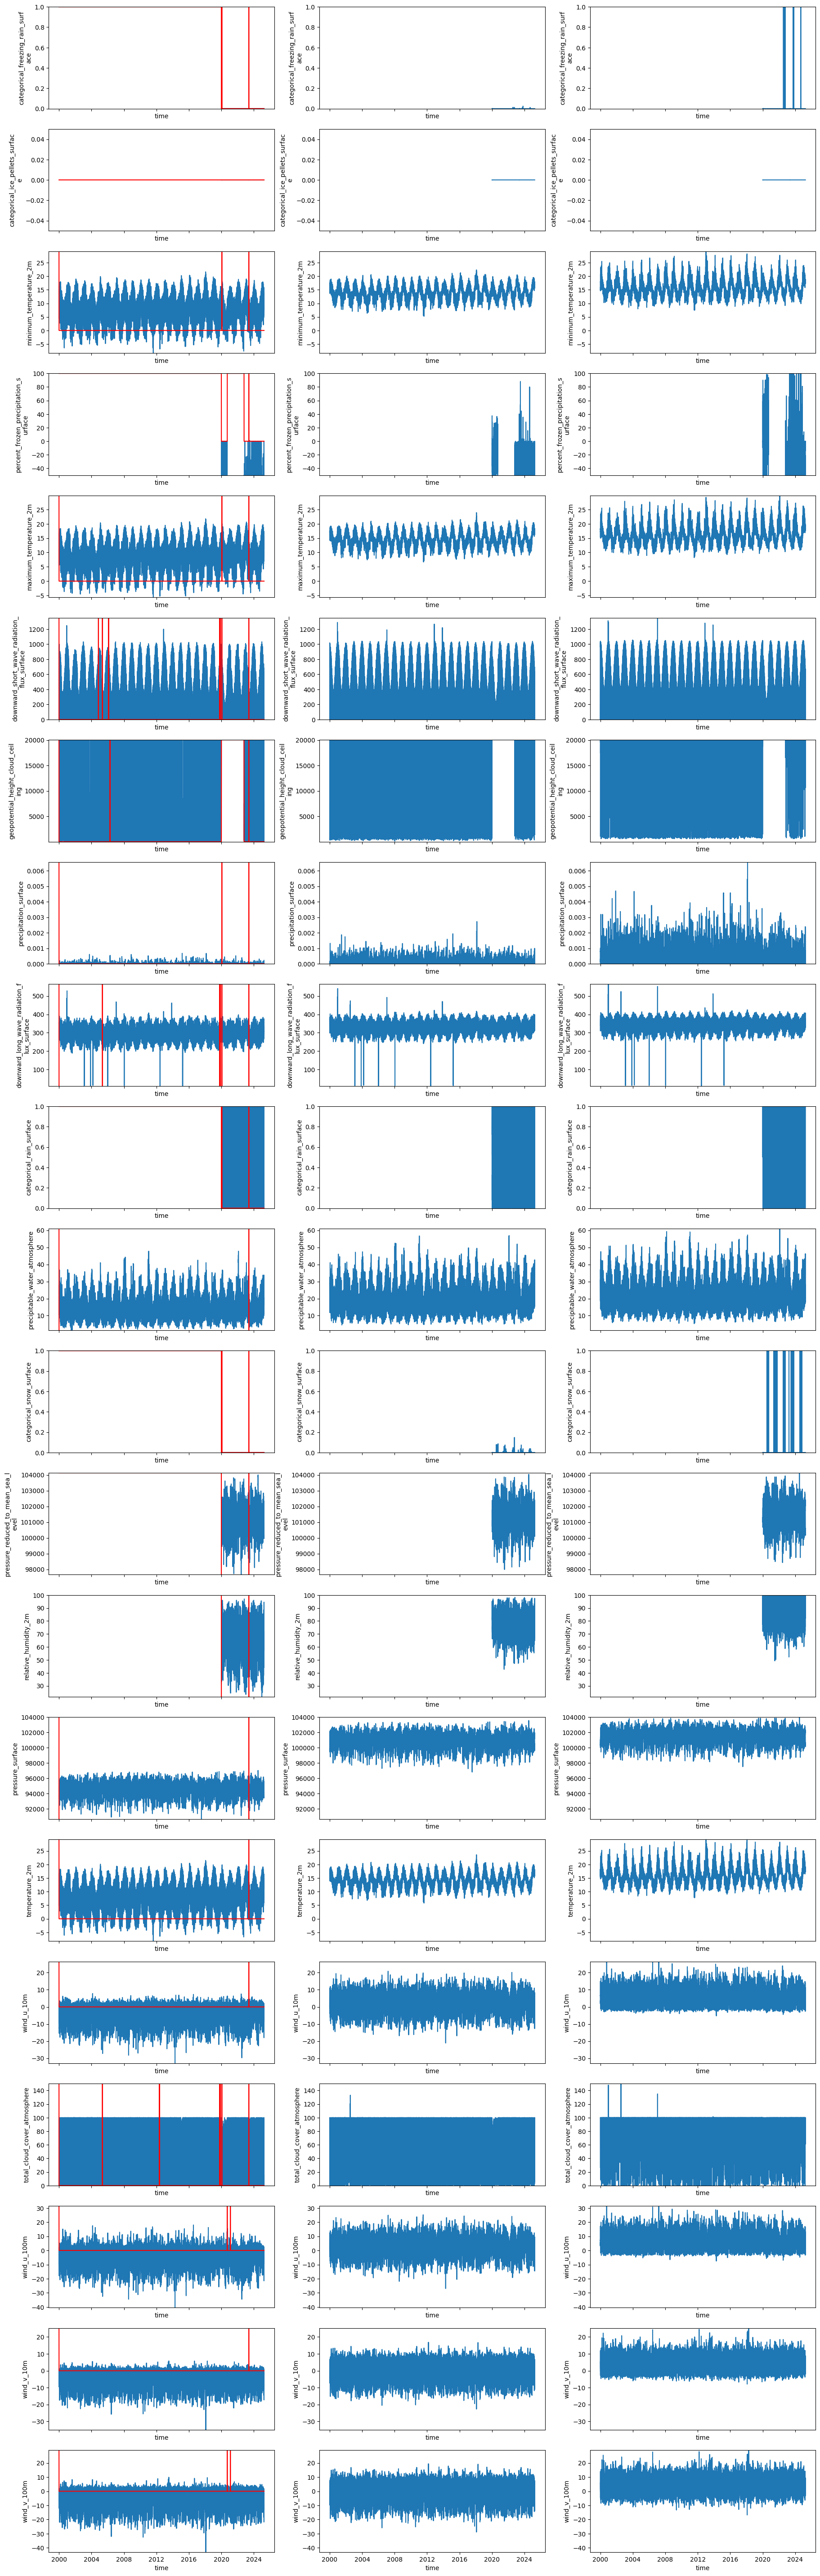

In [3]:
import matplotlib.pyplot as plt
import numpy as np

var_names = list(sorted(ds.data_vars))
fig, axes = plt.subplots(len(var_names), 3, figsize=(22, 3.5 * len(var_names)), sharex=True)

for i, var_name in enumerate(var_names):
    row_axes = axes[i]

    data_array = ds[var_name].sel(latitude=slice(-40,-42), longitude=slice(170,172)).load()
    vmin, vmax = data_array.min(), data_array.max()
    print(var_name, vmin, vmax)

    data_array.min(dim=("latitude", "longitude")).plot(ax=row_axes[0])
    data_array.mean(dim=("latitude", "longitude")).plot(ax=row_axes[1])
    data_array.max(dim=("latitude", "longitude")).plot(ax=row_axes[2])
    (data_array.isnull().any(dim=("latitude", "longitude")) * vmax).plot(ax=row_axes[0], color='red')

    for ax in row_axes:
        ax.set_title("")
        ax.set_ylim(vmin, vmax)

In [ ]:
_ = (
  ds["temperature_2m"]
    # .sel(time=slice("2024-01-01T00:00", "2024-01-03T00:00"))
    # .sel(time=slice("2022-09-01T06:00", "2022-09-02T06:00"))
    .sel(latitude=43.0, longitude=-76.1, method="nearest") # Syracuse, NY
    .plot(size=10, aspect=3)
)

KeyError: "No variable named 'temperature_2m'. Variables on the dataset include ['latitude', 'time', 'spatial_ref', 'longitude', 'precipitation_surface']"

0.1 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/v0.1.0.zarr)>/precipitation_surface/c/1/0/0
0.2 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/v0.1.0.zarr)>/precipitation_surface/c/1/0/0
0.1 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/v0.1.0.zarr)>/precipitation_surface/c/1/0/0
0.2 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/v0.1.0.zarr)>/precipitation_surface/c/1/0/0
0.4 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/v0.1.0.zarr)>/precipitation_surface/c/1/0/0
0.7 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/v0.1.0.zarr)>/precipitation_surface/c/1/0/0
0.4 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/v0.1.0.zarr)>/precipitation_surface/c/1/0/0
0.7 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/v0.1.0.zarr)>/precipitation_

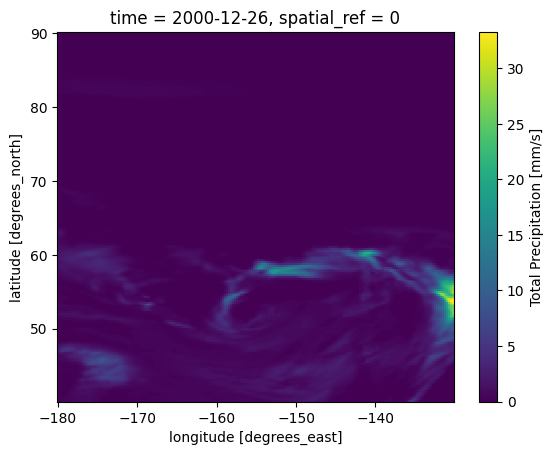

In [4]:
ds["precipitation_surface"].isel(time=ds["precipitation_surface"].encoding["shards"][0], latitude=slice(200), longitude=slice(200)).plot()

decode partial single
decode partial single
decode partial single
decode partial single
decode partial single
decode partial single
decode partial single
decode partial single
0.7 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/vchunks-180d-time-first-dev.zarr)>/temperature_2m/c/25/0/1
1.6 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/vchunks-180d-time-first-dev.zarr)>/temperature_2m/c/25/0/1
0.7 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/vchunks-180d-time-first-dev.zarr)>/temperature_2m/c/25/0/1
1.5 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/vchunks-180d-time-first-dev.zarr)>/temperature_2m/c/25/0/1
1.7 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/vchunks-180d-time-first-dev.zarr)>/temperature_2m/c/25/0/1
1.8 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/vchunks-180d-time-first-dev.zar

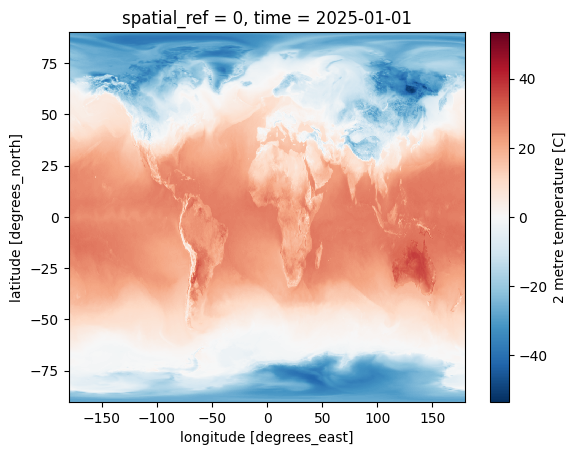

In [11]:
(
  ds["temperature_2m"]
    # .sel(latitude=slice(50, 20), longitude=slice(-100, -50))
    .sel(time="2025-01-01T00:00")
    .plot()
)

In [6]:
(
  ds["temperature_2m"]
    .sel(time="2025-01-01T00:00")
    .sel(latitude=43, longitude=-76, method="nearest") # Syracuse, NY
    .item()
)

decode partial single
2.1 MB, <FsspecStore(HTTPFileSystem, https://data.dynamical.org/noaa/gefs/analysis/vchunks-180d-time-first-dev.zarr)>/temperature_2m/c/25/0/1


6.03125

In [39]:
# Create a dictionary of city coordinates (latitude, longitude)
city_coords = {
    'New York': (40.7128, -74.0060),
    'Atlanta': (33.7490, -84.3880),
    'Mumbai': (19.0760, 72.8777),
    'Sao Paulo': (-23.5505, -46.6333),
}

# Create an xarray Dataset directly from the city coordinates
cities_data = {
    'latitude': ('city', [coords[0] for coords in city_coords.values()]),
    'longitude': ('city', [coords[1] for coords in city_coords.values()])
}
cities_coords = {'city': list(city_coords.keys())}
cities = xr.Dataset(cities_data, coords=cities_coords)

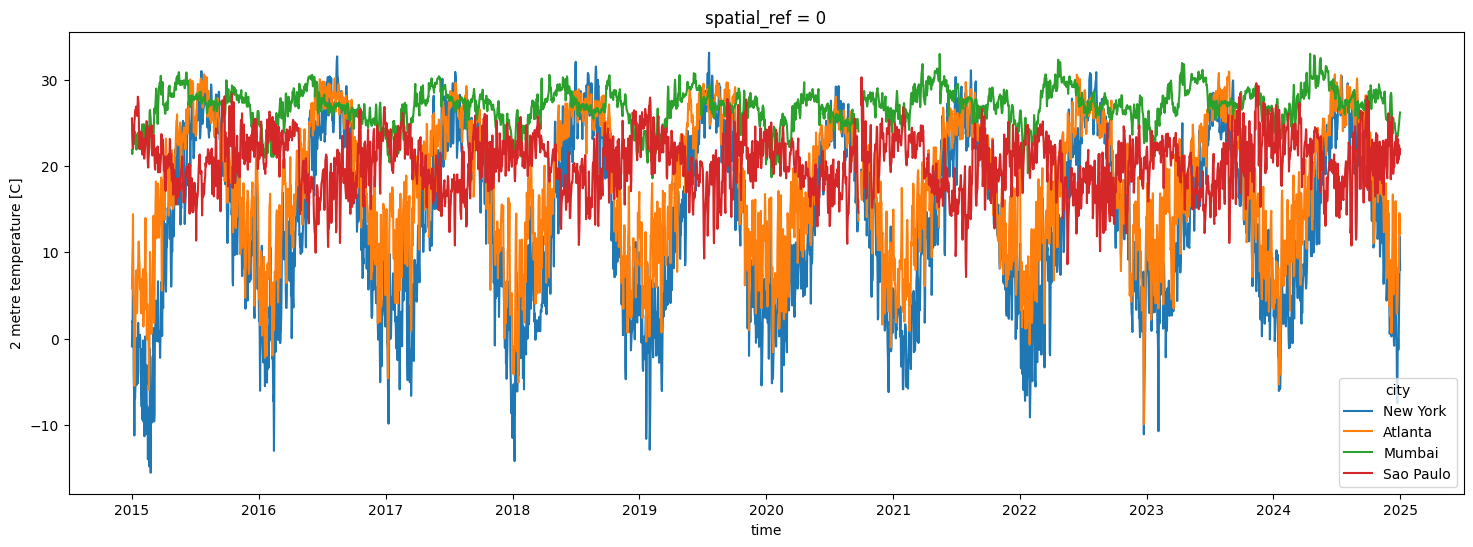

In [43]:
(
  ds["temperature_2m"]
    .sel(time=slice("2015", "2024"))
    .sel(latitude=cities.latitude, longitude=cities.longitude, method="nearest") # Syracuse, NY
    .resample(time="1D").mean()  # daily average 2m temperature
    .plot(hue="city", size=6, aspect=3)
)

loaded


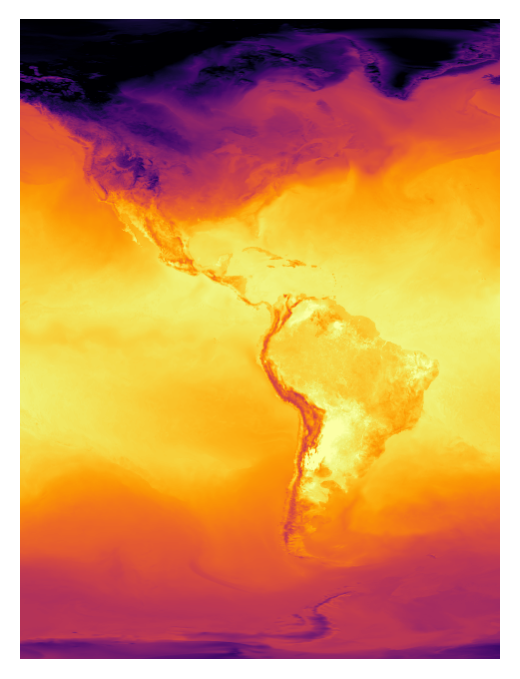

In [4]:
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import xarray as xr

# ds = xr.open_zarr("https://data.dynamical.org/noaa/gfs/forecast/latest.zarr", chunks=None)
ds = xr.open_zarr("s3://us-west-2.opendata.source.coop/dynamical/noaa-gfs-forecast/v0.1.0.zarr", chunks={}, decode_timedelta=True)

data = (
    ds["temperature_2m"]
    .sel(
        init_time=slice("2025-01-01T00", "2025-01-03T00"),
        lead_time=slice('5h'),
        latitude=slice(80, -80),
        longitude=slice(-140, -20),
    )
)
data = data.assign_coords(time=lambda x: x.init_time + x.lead_time)
data = data.stack(time=("init_time", "lead_time")).reset_index("time")
data = data.drop_vars(["init_time", "lead_time"])
data = data.transpose('time', 'latitude', 'longitude')
data = data.load()
print('loaded')



dpi=200
fig, ax = plt.subplots(figsize=(data.longitude.size/dpi, data.latitude.size/dpi), dpi=dpi)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
ax.axis("off")

img = ax.imshow(data.isel(time=0), cmap='inferno', vmin=-30, vmax=30)
anim = FuncAnimation(fig=fig, frames=data, func=lambda frame: img.set_data(frame), interval=60)

anim.save("gfs-americas-temperature.mov")